# Proyek Klasifikasi Gambar: Rice-Image-Dataset
- **Nama:** Reza Nagita Nurhazizah
- **Email:** rezagitta@gmail.com
- **ID Dicoding:** mc179d5x1628

## Import Semua Packages/Library yang Digunakan

In [58]:
# import library yang sering digunakan
import os,random,shutil,pathlib, zipfile

# library pemrosesan gambar
from PIL import Image
from collections import defaultdict

# library untuk plotting
import matplotlib.pyplot as plt

#library membangun model
import tensorflow as tf
import keras

# from tensorflow.keras.preprocessing import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dropout, Dense, GlobalAveragePooling2D, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

## Data Preparation

### Data Loading

dataset yang saya gunakan adalah jenis beras yangs saya dapat melalui [website open source](https://www.muratkoklu.com/datasets/). Namun, saya telah mendownload dan menyimpan dalam google drive

In [3]:
!gdown 1OZujheSZZqMu0QIDvv60qt90TlCdey7f

Downloading...
From (original): https://drive.google.com/uc?id=1OZujheSZZqMu0QIDvv60qt90TlCdey7f
From (redirected): https://drive.google.com/uc?id=1OZujheSZZqMu0QIDvv60qt90TlCdey7f&confirm=t&uuid=9b2203b6-aee7-450d-a2c7-4daf6d804512
To: /content/Rice_Image_Dataset.zip
100% 230M/230M [00:05<00:00, 40.5MB/s]


karena file berbentuk zip maka perlu melakukan unzip file

In [4]:
!unzip Rice_Image_Dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (55).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (550).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5500).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5501).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5502).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5503).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5504).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5505).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5506).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5507).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5508).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5509).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (551).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5510).jpg  
  inflating: Rice_Image_Dataset/Karacadag/K

menampilkan jumlah dan resolusi gambar per kelas pada data jenis beras

In [5]:
# menghitung jumlah gambar masing-masing kelas
def count_image_by_class(dataset_path):
  class_counts ={}
  for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_folder):
      class_counts[class_name] = len(os.listdir(class_folder))

  print("\nJumlah gambar per kelas: ")
  for class_name, count in class_counts.items():
    print(f"- {class_name}: {count} gambar")

  return class_counts

In [6]:
# menghitung jumlah resolusi gambar masing-masing kelas
def count_image_by_resolution(dataset_path):
   resolution_counts = defaultdict(int)

   for class_name in os.listdir(dataset_path):
        class_folder = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_folder):
            for image_name in os.listdir(class_folder):
                image_path = os.path.join(class_folder, image_name)
                try:
                    with Image.open(image_path) as img:
                        resolution = img.size
                        resolution_counts[resolution] += 1
                except:
                    print(f" Gagal membaca {image_path}")

   print("\nJumlah gambar berdasarkan resolusi:")
   for resolution, count in resolution_counts.items():
        print(f"- {resolution}: {count} gambar")

   return resolution_counts

In [7]:
dataset_path = "Rice_Image_Dataset"

count_image_by_class(dataset_path)
count_image_by_resolution(dataset_path)


Jumlah gambar per kelas: 
- Arborio: 15000 gambar
- Ipsala: 15000 gambar
- Jasmine: 15000 gambar
- Karacadag: 15000 gambar
- Basmati: 15000 gambar

Jumlah gambar berdasarkan resolusi:
- (250, 250): 75000 gambar


defaultdict(int, {(250, 250): 75000})

ada 5 kelas (jenis beras) dan masing - masing 15.000 gambar

dataset ini memiliki resolusi gambar (250,250) piksel dapat diartikan resolusi telah konsisten --> dikarenakan kriteria submission harus memiliki gambar dengan resolusi tidak seragam maka saya melakukan resize resolusi gambar secara acak antara 200 hingga 300

In [8]:
def resize_img(dataset_path, min_resolution=200, max_resolution=300):
  for root, dirs, folder in os.walk(dataset_path):
    for file in folder:
      file_path = os.path.join(root,file)

      if file.lower().endswith((".jpg")):
        with Image.open(file_path) as img:
          new_width = random.randint(min_resolution, max_resolution)
          new_height = random.randint(min_resolution, max_resolution)
          # mengubah ukuran
          resized_images = img.resize((new_width, new_height), Image.Resampling.LANCZOS)

          # menyimpan perubahan resolusi gambar
          resized_images.save(file_path)

dataset_path = "/content/Rice_Image_Dataset"

resize_img(dataset_path)

melihat detail info gambar setelah resize resolusi manual secara acak dan menghasilkan resolusi yang bervariasi

In [9]:
dataset_path = "Rice_Image_Dataset"

count_image_by_class(dataset_path)
count_image_by_resolution(dataset_path)

Streaming output truncated to the last 5000 lines.
- (231, 291): 7 gambar
- (247, 278): 6 gambar
- (283, 270): 7 gambar
- (224, 282): 9 gambar
- (289, 250): 10 gambar
- (211, 246): 8 gambar
- (244, 249): 9 gambar
- (201, 213): 8 gambar
- (247, 240): 5 gambar
- (234, 217): 6 gambar
- (287, 273): 3 gambar
- (243, 231): 8 gambar
- (233, 266): 8 gambar
- (255, 252): 9 gambar
- (290, 271): 9 gambar
- (278, 283): 10 gambar
- (278, 214): 14 gambar
- (201, 269): 5 gambar
- (287, 218): 8 gambar
- (256, 237): 4 gambar
- (233, 284): 8 gambar
- (242, 244): 5 gambar
- (220, 260): 11 gambar
- (241, 270): 9 gambar
- (216, 238): 6 gambar
- (292, 273): 6 gambar
- (279, 206): 7 gambar
- (229, 231): 11 gambar
- (290, 267): 12 gambar
- (284, 298): 11 gambar
- (239, 212): 4 gambar
- (245, 293): 3 gambar
- (212, 231): 8 gambar
- (214, 204): 9 gambar
- (245, 299): 5 gambar
- (227, 267): 11 gambar
- (226, 278): 7 gambar
- (285, 289): 5 gambar
- (279, 260): 10 gambar
- (216, 267): 7 gambar
- (208, 250): 6 gamb

defaultdict(int,
            {(221, 296): 11,
             (211, 243): 11,
             (287, 295): 9,
             (275, 253): 6,
             (287, 288): 9,
             (244, 244): 7,
             (211, 300): 11,
             (238, 213): 8,
             (262, 225): 10,
             (223, 244): 9,
             (248, 233): 9,
             (287, 252): 13,
             (205, 222): 8,
             (202, 228): 6,
             (282, 236): 11,
             (214, 256): 10,
             (255, 240): 6,
             (255, 210): 16,
             (213, 263): 11,
             (201, 297): 9,
             (211, 268): 6,
             (299, 286): 7,
             (204, 288): 10,
             (295, 203): 7,
             (293, 229): 5,
             (276, 212): 7,
             (264, 221): 12,
             (272, 261): 14,
             (255, 268): 10,
             (281, 223): 12,
             (205, 209): 9,
             (227, 256): 9,
             (244, 272): 12,
             (276, 299): 6,
             (22

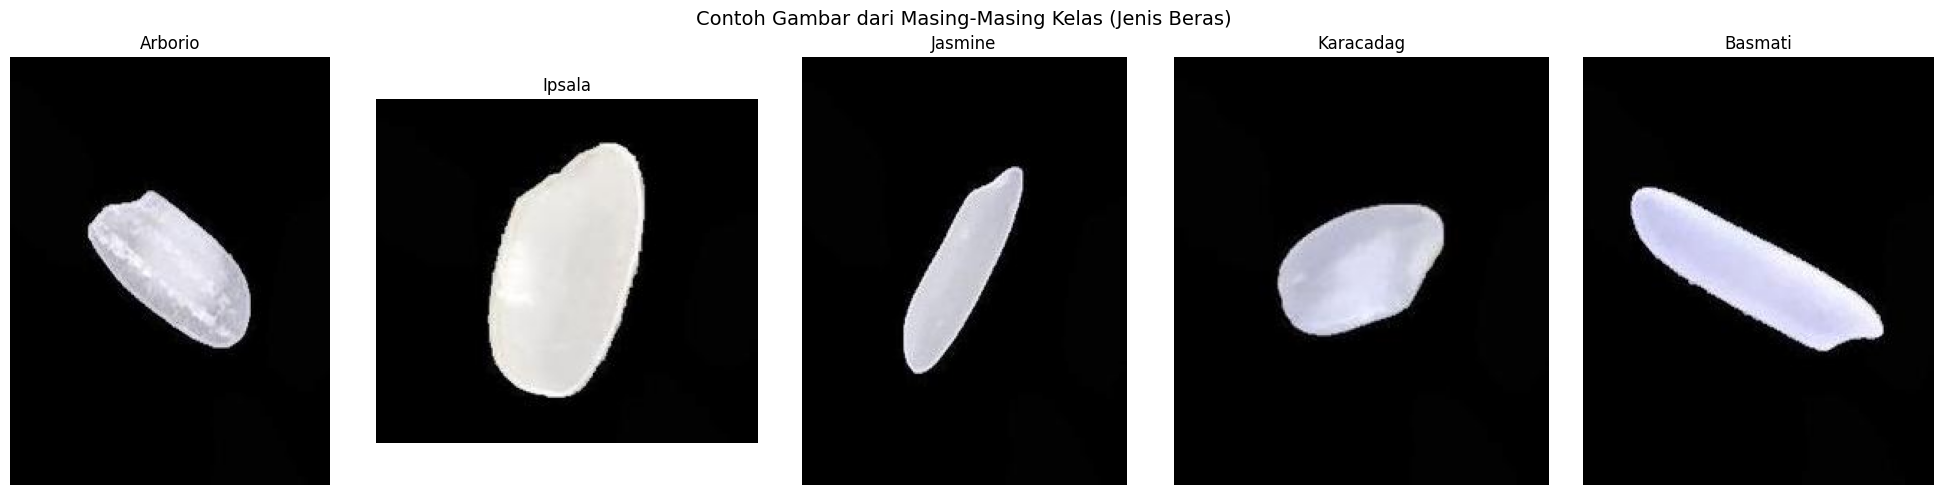

In [10]:
def show_example_image(dataset_path):
    class_images = {}

    # Ambil satu gambar acak dari setiap kelas
    for root, dirs, files in os.walk(dataset_path):
        if files:
            class_name = os.path.basename(root)
            image_files = [f for f in files if f.lower().endswith(('.jpg'))]
            if image_files:
                random_image = random.choice(image_files)
                class_images[class_name] = os.path.join(root, random_image)

    fig, axes = plt.subplots(1, len(class_images), figsize=(4 * len(class_images), 5))
    fig.suptitle('Contoh Gambar dari Masing-Masing Kelas (Jenis Beras)', fontsize=14)

    if len(class_images) == 1:
        axes = [axes]

    for ax, (class_name, image_path) in zip(axes, class_images.items()):
        img = Image.open(image_path)
        ax.imshow(img)
        ax.set_title(class_name)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


dataset_path = "Rice_Image_Dataset"

show_example_image(dataset_path)

In [11]:
def counts_image(dataset_path):
    total_count = 0
    image_exts = ('.jpg')

    for root, dirs, files in os.walk(dataset_path):
        image_files = [f for f in files if f.lower().endswith(image_exts)]
        total_count += len(image_files)

    return total_count

dataset_path = "Rice_Image_Dataset"
total_count = counts_image(dataset_path)

print(f"Jumlah total gambar jenis beras dalam dataset: {total_count}")

Jumlah total gambar jenis beras dalam dataset: 75000


### Data Preprocessing

split dataset menjadi train(70%), validation (15%), dan test(15%)

#### Split Dataset

In [12]:
def split_dataset(dataset_path, output_path, train_ratio=0.7, val_ratio=0.1):

    # membuat folder utama untuk dataset hasil split
    os.makedirs(output_path, exist_ok=True)

    #mmembuat folder train, val, test di dalam output_path
    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(output_path, split), exist_ok=True)

    # Ambil semua kategori (hanya folder, bukan file)
    categories = [cat for cat in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, cat))]

    for category in categories:
        category_path = os.path.join(dataset_path, category)
        print(f"Memproses kategori: {category}")

        # membuatfolder kategori di dalam train, val, test
        for split in ["train", "val", "test"]:
            os.makedirs(os.path.join(output_path, split, category), exist_ok=True)

        # mengambil semua file gambar dan acak urutannya
        images = [f for f in os.listdir(category_path) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
        random.shuffle(images)

        # menghitung jumlah gambar untuk setiap subset
        train_count = int(len(images) * train_ratio)
        val_count = int(len(images) * val_ratio)

        # Bagi gambar ke dalam masing-masing set
        splits = {
            "train": images[:train_count],
            "val": images[train_count:train_count + val_count],
            "test": images[train_count + val_count:]
        }

        # Salin gambar ke folder baru (tidak menimpa dataset asli)
        for split, image_list in splits.items():
            for img in image_list:
                src = os.path.join(category_path, img)
                dst = os.path.join(output_path, split, category, img)
                shutil.copy2(src, dst)  # Copy file tanpa menghapus aslinya

    print("Split dataset selesai.")


dataset_path = "Rice_Image_Dataset"
output_path = "Rice_Image_Dataset_Split"

split_dataset(dataset_path, output_path)

Memproses kategori: Arborio
Memproses kategori: Ipsala
Memproses kategori: Jasmine
Memproses kategori: Karacadag
Memproses kategori: Basmati
Split dataset selesai.


melakukan pra pemrosesan dengan rescle dan normalisasi pada data train,test, dan validation serta melakukan augmentasi pada data train, guna membantu model belajar lebih bervariasi

In [13]:
def preprocessing_dt(train_dir, val_dir, test_dir, target_size=(150,150), batch_size=32):
  train_data = ImageDataGenerator(
      rescale=1./255,
      rotation_range=20,
      horizontal_flip=True,
      zoom_range=0.2,
      fill_mode='nearest'
  )

  #resclae validation & test
  test_val_data = ImageDataGenerator(rescale=1./255)

  # Generator untuk masing-masing subset
  train_generator = train_data.flow_from_directory(
      train_dir,
      target_size=target_size,
      batch_size=batch_size,
      class_mode='categorical',
      shuffle=True
  )
  val_generator = test_val_data.flow_from_directory(
        val_dir,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

  test_generator = test_val_data.flow_from_directory(
        test_dir,
        target_size=target_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

  return train_generator, val_generator, test_generator

In [14]:
train_dir='/content/Rice_Image_Dataset_Split/train'
val_dir='/content/Rice_Image_Dataset_Split/val'
test_dir= '/content/Rice_Image_Dataset_Split/test'

train_gen, val_gen, test_gen = preprocessing_dt(train_dir, val_dir, test_dir)

Found 52500 images belonging to 5 classes.
Found 7500 images belonging to 5 classes.
Found 15000 images belonging to 5 classes.


kelas-kelas dalam dataset jenis beras

In [15]:
class_indices = train_gen.class_indices
print(class_indices)

{'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3, 'Karacadag': 4}


## Modelling

Melakukan transfer learning dengan model MobileNetV2 karena cocok untuk model saya, training cepat dan ringan. freeze layers supaya bobot tetap seperti saat dilatih dalam imageNet.

In [16]:
# Inisialisasi pretrained model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# freeze bobot pretrained model
for layer in base_model.layers:
    layer.trainable = False

# Membangun model secara berurutan
model = Sequential()

# Menambahkan backbone pretrained
model.add(base_model)

# Layer tambahan Conv2D dan Pooling
model.add(Conv2D(48, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(96, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Menyusun layer akhir klasifikasi
model.add(Flatten())
model.add(Dropout(0.4))
model.add(Dense(128, activation='relu'))
model.add(Dense(5, activation='softmax'))

<ipython-input-16-a5cf6f44c117>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


compile model : menyusun konfigurasi model sebelum training
dengan,
* optimizer : bagaimana model belajar? (salah satunya dengan adam),
* loss fuction: bagaimana model menghitung kesalahan? (dengan categorical_crossentropy untuk multi kelas)
* metrics accuracy : apa yang ingin diukur selama training/ mengetahui performanya? (salah satunya dengan accuracy)

In [17]:
optimizer = Adam (learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

membuat callback untuk memantau val_accuracy dan menghentikan model saat training ketika telah mencapai target

In [18]:
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    mode='min'
)

In [19]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[checkpoint, earlystop],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 1784s 1s/step - accuracy: 0.8914 - loss: 0.3033 - val_accuracy: 0.9763 - val_loss: 0.0677
Epoch 2/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 1753s 1s/step - accuracy: 0.9722 - loss: 0.0873 - val_accuracy: 0.9749 - val_loss: 0.0762
Epoch 3/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 1732s 1s/step - accuracy: 0.9749 - loss: 0.0764 - val_accuracy: 0.9676 - val_loss: 0.0914
Epoch 4/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 1733s 1s/step - accuracy: 0.9772 - loss: 0.0687 - val_accuracy: 0.9693 - val_loss: 0.0819
Epoch 5/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 1754s 1s/step - accuracy: 0.9812 - loss: 0.0577 - val_accuracy: 0.9831 - val_loss: 0.0526
Epoch 6/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 1782s 1s/step - accuracy: 0.9828 - loss: 0.0566 - val_accuracy: 0.9524 - val_loss: 0.1551
Epoch 7/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 1733s 1s/step - accuracy: 0.9805 - loss: 0.0579 - val_accuracy: 0.9824 - val_loss: 0.0489
Epoch 8/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 1780s 1s/step - accuracy: 0.9816 -

## Evaluasi dan Visualisasi

In [20]:
# Cek akurasi
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
test_loss, test_acc = model.evaluate(test_gen, verbose=1)

print(f"Training Accuracy: {train_acc:.2%}")
print(f"Validation Accuracy: {val_acc:.2%}")
print(f"Test Accuracy: {test_acc:.2%}")

469/469 ━━━━━━━━━━━━━━━━━━━━ 351s 749ms/step - accuracy: 0.9890 - loss: 0.0348
Training Accuracy: 98.46%
Validation Accuracy: 97.25%
Test Accuracy: 98.41%


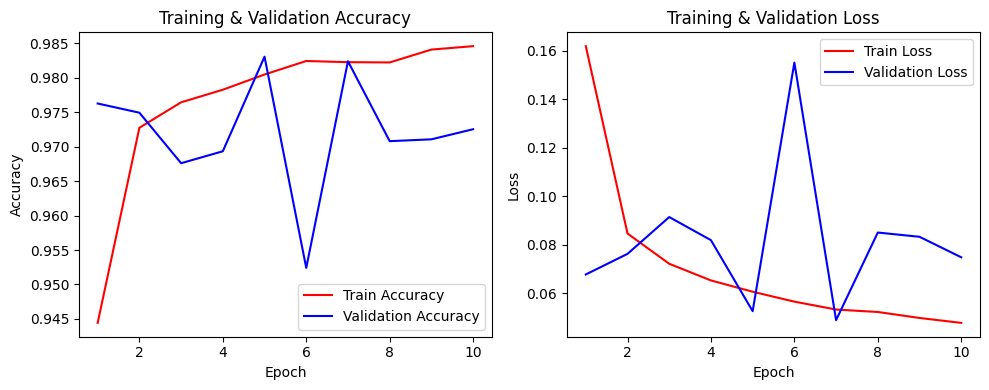

In [21]:
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Plot akurasi
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'r', label='Train Accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'r', label='Train Loss')
    plt.plot(epochs, val_loss, 'b', label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

## Konversi Model

### konversi model ke tensorflow.js (TFJS)

In [22]:
model.save("rice_model.h5")

In [23]:
! pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 845.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 81.2 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found ex

In [24]:
!tensorflowjs_converter --input_format=keras rice_model.h5 rice_model_tfjs

2025-04-08 11:35:36.183835: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744112136.288800   76247 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744112136.310023   76247 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744112136.378128   76247 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744112136.378225   76247 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744112136.378238   76247 computation_placer.cc:177] computation placer alr

mengubah model konverversi model .tfjs menjadi zip

In [26]:
shutil.make_archive('rice_model_tfjs', 'zip', 'rice_model_tfjs')

'/content/rice_model_tfjs.zip'

### mengonversi model menjadi format .saved_model

In [28]:
# load model dari h5
model = tf.keras.models.load_model("rice_model.h5")

# simpan dalam format savedmodel
model.export("rice_saved_model")

Saved artifact at 'rice_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140253855664080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253855666192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253855666576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253855666384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253855664272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253855667728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253855668112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253855668496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253855668304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253855665616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1402538556696

mengubah model .saved_model ke zip

In [29]:
# Folder model SavedModel
folder_path = '/content/rice_saved_model'

# Path output zip (tanpa ekstensi .zip)
output_zip = '/content/rice_saved_model'

# Zip folder
shutil.make_archive(output_zip, 'zip', folder_path)

'/content/rice_saved_model.zip'

### mengonversi .TFLITE

In [60]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan ke file
with open('rice_model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpi900gch2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140253802783248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253802781904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253802780176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253802780752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253802782864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253802780368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253802781328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253802780944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253802781520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140253802782288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1402538027849

menambahkan label.txt pada model tflite dan membuat folder zip

In [61]:
labels = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
with open('labels.txt', 'w') as f:
    f.write('\n'.join(labels))

# 3. Buat folder dan pindahkan file ke dalamnya
os.makedirs('rice_tflite', exist_ok=True)
os.rename('rice_model.tflite', 'rice_tflite/rice_model.tflite')
os.rename('labels.txt', 'rice_tflite/labels.txt')

# 4. Kompres ke zip
zip_path = 'rice_tflite.zip'
with zipfile.ZipFile(zip_path, 'w') as zipf:
    zipf.write('rice_tflite/rice_model.tflite', arcname='/content/rice_model.tflite')
    zipf.write('rice_tflite/labels.txt', arcname='labels.txt')

print("Selesai: 'rice_tflite.zip' siap digunakan.")

Selesai: 'rice_tflite.zip' siap digunakan.


membuat folder hasil dari kalsifikasi gambar

In [31]:
# Buat kelas yang akan ditulis ke dalam file
kelas = """Arborio
Jasmine
Basmati
Karacadag
Ipsala"""

# simpan path dan nama file
simpan_file = "/content/Hasil_klasifikasi_Gambar.txt"

# menulis(W) kelas ke dalam file
with open(simpan_file, "w") as file:
    file.write(kelas)

membuat file requirement

In [32]:
!pip freeze > requirements.txt

## Inference (Optional)

inference di browser menggunakan TFJS


In [42]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

In [55]:
# Load model .h5
model = load_model("rice_model.h5")

# Label kelas
labels = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = model.predict(img_array)
    predicted_class_index = np.argmax(prediction)
    predicted_class_name = labels[predicted_class_index]

    print(f"Prediksi: {predicted_class_name}")
    return predicted_class_name

In [56]:
predict_image("Rice_Image_Dataset/Jasmine/Jasmine (7775).jpg")
predict_image("Rice_Image_Dataset/Arborio/Arborio (5266).jpg")
predict_image("Rice_Image_Dataset/Basmati/basmati (12991).jpg")
predict_image("Rice_Image_Dataset/Karacadag/Karacadag (12533).jpg")
predict_image("Rice_Image_Dataset/Ipsala/Ipsala (9752).jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediksi: Jasmine
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Prediksi: Arborio
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Prediksi: Basmati
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Prediksi: Karacadag
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Prediksi: Ipsala


'Ipsala'